In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'xgboost'

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [4]:
df['Exited'].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [5]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['CreditScoreAge'] = df['CreditScore'] / df['Age']
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,CreditScoreAge,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,14.738095,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,0.744670,14.829268,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,1.401362,11.952381,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,17.923077,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,1.587035,19.767442,False,True,False


In [7]:
X = df.drop(columns=['Exited'])
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
log_pred = log_reg.predict(X_test_scaled)
log_acc = accuracy_score(y_test, log_pred)
log_acc

0.8175

In [9]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_acc

0.86

In [10]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_acc

0.855

In [11]:
pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [log_acc, rf_acc, xgb_acc]
}).sort_values('Accuracy', ascending=False)

,Model,Accuracy
1,Random Forest,0.8600
2,XGBoost,0.8550
0,Logistic Regression,0.8175


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = {
    'n_estimators': [300, 500],
    'max_depth': [None, 10, 15],
    'min_samples_split': [2, 5]
}

rf_search = GridSearchCV(RandomForestClassifier(random_state=42), rf_grid, cv=cv, scoring='accuracy', n_jobs=-1)
rf_search.fit(X_train, y_train)
rf_search.best_params_

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 500}

In [13]:
xgb_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_search = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), xgb_grid, cv=cv, scoring='accuracy', n_jobs=-1)
xgb_search.fit(X_train, y_train)
xgb_search.best_params_

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

In [14]:
best_rf = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_

rf_tuned_acc = accuracy_score(y_test, best_rf.predict(X_test))
xgb_tuned_acc = accuracy_score(y_test, best_xgb.predict(X_test))

pd.DataFrame({
    'Model': ['Random Forest (tuned)', 'XGBoost (tuned)'],
    'Accuracy': [rf_tuned_acc, xgb_tuned_acc]
}).sort_values('Accuracy', ascending=False)

,Model,Accuracy
1,XGBoost (tuned),0.8695
0,Random Forest (tuned),0.8670


In [15]:
best_model = best_xgb if xgb_tuned_acc >= rf_tuned_acc else best_rf
best_pred = best_model.predict(X_test)
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



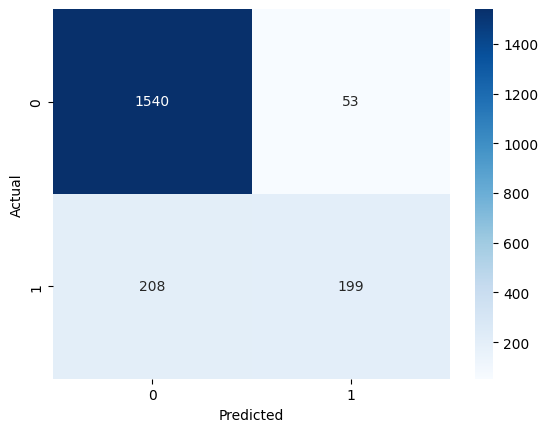

In [16]:
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

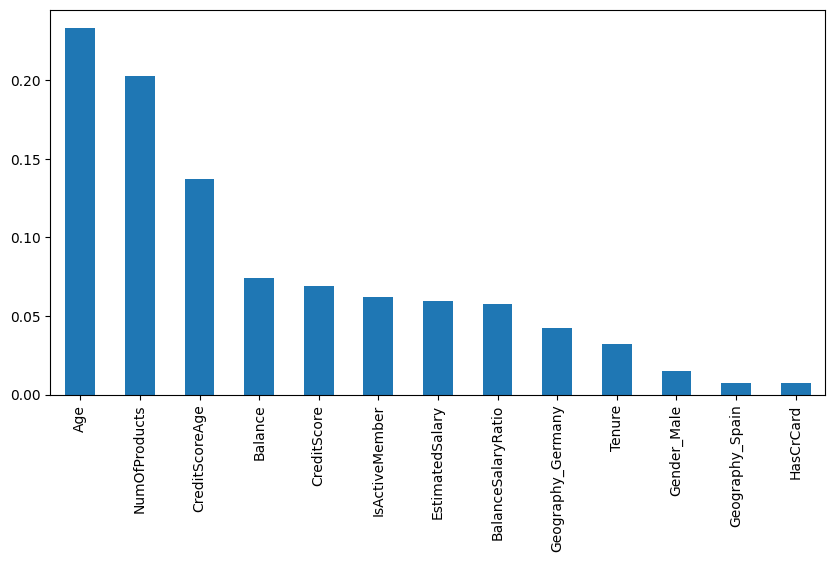

In [17]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(10, 5))
plt.show()

In [18]:
final_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Random Forest (tuned)', 'XGBoost (tuned)'],
    'Accuracy': [log_acc, rf_acc, xgb_acc, rf_tuned_acc, xgb_tuned_acc]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)
final_results

,Model,Accuracy
0,XGBoost (tuned),0.8695
1,Random Forest (tuned),0.8670
2,Random Forest,0.8600
3,XGBoost,0.8550
4,Logistic Regression,0.8175
